https://www.kaggle.com/datasets/amanalisiddiqui/fraud-detection-dataset?resource=download

Dataset "Fraud Detection Dataset" trên Kaggle của tác giả Aman Ali Siddiqui là một tập dữ liệu rất nổi tiếng (thường bắt nguồn từ mô phỏng dữ liệu giao dịch tài chính di động/Mobile Money, tương tự như bài toán kinh điển PaySim).   

1. Bản chất của Dataset này là gì?Mục tiêu: Xây dựng mô hình Machine Learning để phân loại/dự đoán xem một giao dịch tài chính có phải là gian lận (Fraud) hay không (Bài toán Phân loại nhị phân - Binary Classification: 0 là giao dịch bình thường, 1 là gian lận).Đặc thù lớn nhất: Đây là bài toán mất cân bằng dữ liệu cực đoan (Class Imbalance). Trong thực tế, số lượng giao dịch gian lận chiếm tỷ lệ vô cùng nhỏ (thường dưới 1%), còn lại hơn 99% là giao dịch hợp lệ. Nếu bạn dùng mô hình dự đoán toàn là "0" thì độ chính xác (Accuracy) vẫn có thể lên tới 99% nhưng mô hình lại hoàn toàn vô tích sự vì bỏ sót 100% các vụ lừa đảo.   

2. Các cột dữ liệu (Features) thường gặp trong Dataset này:   Mặc dù các biến có thể dao động tùy theo phiên bản file CSV cụ thể, tập dữ liệu này mô phỏng các giao dịch ngân hàng/ví điện tử qua các cột chính sau:   step: Đại diện cho đơn vị thời gian (ví dụ: 1 bước = 1 giờ). Tổng số step thường kéo dài qua nhiều ngày để thấy chuỗi thời gian diễn ra giao dịch.type: Loại giao dịch tài chính, bao gồm các hình thức phổ biến:CASH-IN: Nạp tiền vào tài khoản.CASH-OUT: Rút tiền mặt từ merchant/tài khoản.DEBIT: Chuyển tiền từ dịch vụ di động sang tài khoản ngân hàng.   PAYMENT: Thanh toán mua sắm hàng hóa/dịch vụ.TRANSFER: Chuyển khoản cho người dùng khác trên cùng nền tảng.amount: Số tiền của giao dịch (Giao dịch gian lận thường có các khoản tiền bất thường so với lịch sử người dùng).   nameOrig: Mã định danh (ID) của khách hàng thực hiện giao dịch trước khi chuyển đi.oldbalanceOrg: Số dư tài khoản của người gửi trước khi thực hiện giao dịch.newbalanceOrig: Số dư tài khoản của người gửi sau khi thực hiện giao dịch.nameDest: Mã định danh (ID) của người nhận tiền phía bên kia.oldbalanceDest: Số dư ban đầu của người nhận trước khi nhận tiền.newbalanceDest: Số dư của người nhận sau khi nhận tiền.isFraud: Nhãn mục tiêu (Target Label) cần dự đoán. 1 nếu là giao dịch gian lận do kẻ gian chiếm đoạt tài khoản chuyển tiền đi, 0 nếu là giao dịch sạch.isFlaggedFraud: Cờ cảnh báo của hệ thống quy tắc cũ (Rule-based system) khi phát hiện một giao dịch có số tiền chuyển khoản quá lớn trong một lần (thường là > 200,000).

3. Những điểm cần lưu ý khi làm Machine Learning với Dataset này:Không dùng mô hình Hồi quy tuyến tính (Linear Regression):Vì bài toán này là Phân loại (Classification) chứ không phải dự đoán giá trị liên tục như dự đoán điểm số (Exam Score), bạn phải chuyển sang dùng các mô hình phân loại như:   LogisticRegression (Hồi quy logistic)RandomForestClassifier (Rừng ngẫu nhiên phân loại)XGBoost / LightGBM (Các mô hình cực mạnh chuyên trị dữ liệu bảng và chống mất cân bằng dữ liệu).Cách xử lý dữ liệu mất cân bằng (Imbalanced Data):Phải dùng kỹ thuật cân bằng dữ liệu như SMOTE (Synthetic Minority Over-sampling Technique) để sinh thêm mẫu giả lập cho bên gian lận.Không dùng độ đo Accuracy để đánh giá mô hình. Thay vào đó, bắt buộc phải dùng Precision, Recall, F1-Score và đặc biệt là ROC-AUC Score.   Feature Engineering (Tạo đặc trưng mới):Bạn có thể tự tạo thêm các cột mới để giúp mô hình thông minh hơn, ví dụ:Kiểm tra xem số dư sau giao dịch của người gửi (newbalanceOrig) có khớp với công thức oldbalanceOrg - amount hay không (kẻ gian thường làm lệch con số này).Tính toán độ lệch số tiền so với mức trung bình của tài khoản đó.

In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [67]:
import warnings
warnings.filterwarnings("ignore")
sns.set(style="whitegrid")

In [68]:
df = pd.read_csv("AIML Dataset.csv")

In [69]:
df.shape

(6362620, 11)

In [70]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [71]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [72]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

In [73]:
df["isFraud"].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [74]:
df["isFlaggedFraud"].value_counts()

isFlaggedFraud
0    6362604
1         16
Name: count, dtype: int64

In [75]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [76]:
df.duplicated().sum()

np.int64(0)

In [77]:
# % is Fraud / all data
round((df["isFraud"].value_counts()[1] / df.shape[0]) *100,2)

np.float64(0.13)

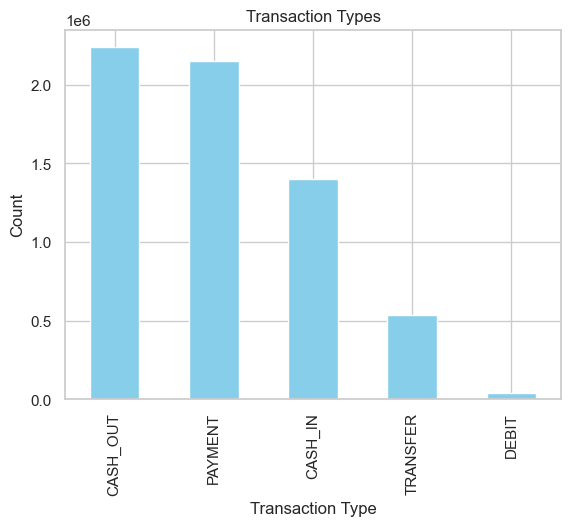

In [78]:
df["type"].value_counts().plot(kind='bar', title="Transaction Types", color="skyblue")
plt.xlabel("Transaction Type")
plt.ylabel("Count")
plt.show()

Text(0, 0.5, 'Fraud Rate')

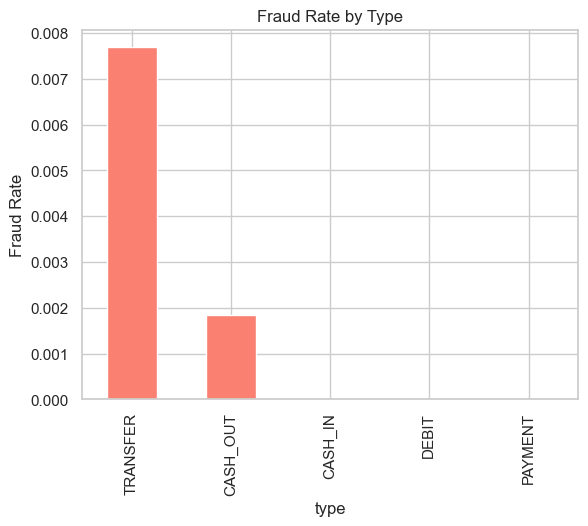

In [79]:
fraud_by_type = df.groupby("type")["isFraud"].mean().sort_values(ascending=False)
fraud_by_type.plot(kind="bar", title="Fraud Rate by Type", color="salmon")
plt.ylabel("Fraud Rate")

In [80]:
fraud_by_type

type
TRANSFER    0.007688
CASH_OUT    0.001840
CASH_IN     0.000000
DEBIT       0.000000
PAYMENT     0.000000
Name: isFraud, dtype: float64

In [81]:
df["amount"].describe().astype(int)

count     6362620
mean       179861
std        603858
min             0
25%         13389
50%         74871
75%        208721
max      92445516
Name: amount, dtype: int64

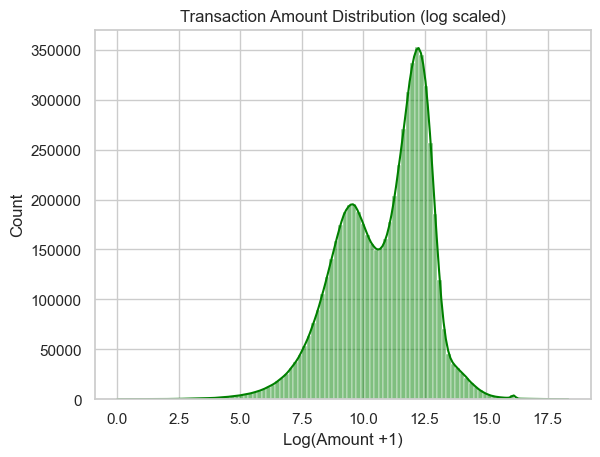

In [82]:
sns.histplot(np.log1p(df["amount"]), bins=100, kde=True, color="green")
plt.title("Transaction Amount Distribution (log scaled)")
plt.xlabel("Log(Amount +1)")
plt.show()

1. np.log1p(df["amount"])Bản chất: Hàm log1p(x) tính giá trị $\ln(1 + x)$ cho từng phần tử trong cột amount.Lý do cần dùng: Trong các bài toán tài chính (như PaySim), số tiền giao dịch thường có dạng phân phối lệch phải cực đoan (Right-Skewed). Tức là phần lớn các giao dịch có số tiền nhỏ, nhưng lại có một vài giao dịch có số tiền khổng lồ lên tới hàng triệu hoặc hàng tỷ. Nếu vẽ biểu đồ trực tiếp với số tiền gốc, biểu đồ sẽ bị dồn cục ở một góc và rất khó quan sát.Phép biến đổi $\log(1 + x)$ giúp "nén" các giá trị lớn lại, làm cho phân phối trở nên trực quan, cân đối hơn và dễ nhìn ra các xu hướng ẩn bên trong dữ liệu. (Cộng thêm 1 để tránh lỗi toán học khi gặp giá trị giao dịch bằng 0).

Đoạn code trên dùng để vẽ biểu đồ phân phối (histogram kết hợp đường mật độ KDE) cho số tiền giao dịch (amount) sau khi đã biến đổi logarit.

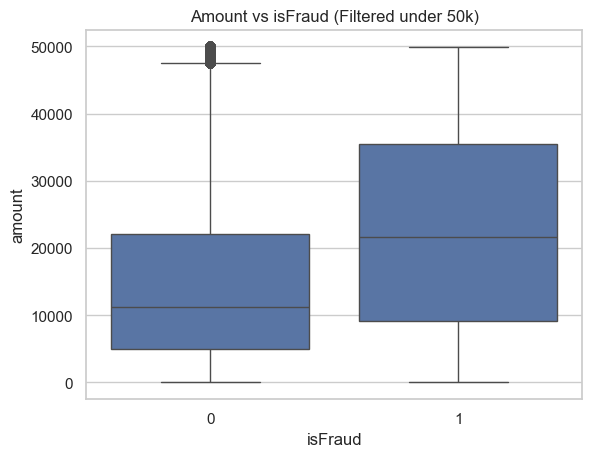

In [83]:
sns.boxplot(data=df[df["amount"] < 50000], x = "isFraud", y="amount")
plt.title("Amount vs isFraud (Filtered under 50k)")
plt.show()

vẽ biểu đồ hộp (Boxplot) nhằm so sánh phân phối số tiền giao dịch (amount) giữa hai nhóm: Giao dịch bình thường (isFraud = 0) và Giao dịch gian lận (isFraud = 1), với điều kiện chỉ xét các giao dịch có số tiền dưới 50,000.

In [84]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

In [85]:
df["balanceDiffOrig"] = df["oldbalanceOrg"] - df["newbalanceOrig"]
df["balanceDiffDest"] = df["newbalanceDest"] - df["oldbalanceDest"]



1. df["balanceDiffOrig"] = df["oldbalanceOrg"] - df["newbalanceOrig"]
Ý nghĩa: Tính toán số tiền thực tế bị trừ trong tài khoản của người gửi (Số dư trước trừ đi Số dư sau).

Ứng dụng trong phát hiện gian lận:

Trong một giao dịch bình thường, số tiền bị trừ ở tài khoản người gửi (oldbalanceOrg - newbalanceOrig) phải khớp (hoặc gần khớp) với số tiền giao dịch (amount).

Kẻ gian (Fraudster) khi chiếm đoạt tài khoản thường có hành vi rút sạch tiền (newbalanceOrig về 0 ngay lập tức mặc dù số dư cũ rất lớn). Việc tạo cột chênh lệch này giúp mô hình Machine Learning dễ dàng nhận diện các mẫu hành vi vét cạn tài khoản này.

2. df["balanceDiffDest"] = df["newbalanceDest"] - df["oldbalanceDest"]
Ý nghĩa: Tính toán số tiền thực tế tăng lên trong tài khoản của người nhận (Số dư mới trừ đi Số dư cũ).

Ứng dụng trong phát hiện gian lận:

Ở các giao dịch hợp lệ, số tiền cộng vào tài khoản người nhận thường tương ứng với số tiền chuyển. Tuy nhiên, trong tập dữ liệu này, có rất nhiều tài khoản đích (đặc biệt là các tài khoản nhận tiền do bot/kẻ gian lập ra) có đặc điểm là số dư không thay đổi đúng cách hoặc có sự bất thường lớn giữa lượng tiền chuyển và thực tế số dư thay đổi.

In [86]:
(df["balanceDiffOrig"] < 0).sum()

np.int64(1399253)

đếm tổng số lượng giao dịch mà tại đó số dư mới của người gửi (newbalanceOrig) lớn hơn số dư cũ (oldbalanceOrg).

Trong tập dữ liệu PaySim, hiện tượng số dư tài khoản người gửi tăng lên sau khi chuyển/rút tiền (newbalanceOrig > oldbalanceOrg) hoặc các lỗi hệ thống/dấu hiệu hack tài khoản xuất hiện rất nhiều ở các giao dịch gian lận. Câu lệnh này giúp bạn nhanh chóng kiểm tra xem tập dữ liệu của bạn có bao nhiêu trường hợp "bất thường về mặt logic nghiệp vụ" như vậy.

In [87]:
(df["balanceDiffDest"] < 0).sum()

np.int64(1238864)

để đếm tổng số lượng giao dịch mà tại đó số dư mới của người nhận (newbalanceDest) lại nhỏ hơn số dư cũ (oldbalanceDest).

Thông thường trong các giao dịch chuyển tiền, tài khoản người nhận phải tăng lên hoặc giữ nguyên (nếu có lỗi hệ thống hoặc không đúng bản chất). Việc tài khoản người nhận bị giảm tiền sau một giao dịch chuyển đến là một hiện tượng bất thường về mặt logic toán học/nghiệp vụ. Lệnh này giúp bạn kiểm tra xem tập dữ liệu có bao nhiêu giao dịch kỳ lạ như vậy để có hướng xử lý (ví dụ: làm sạch dữ liệu hoặc giữ lại làm đặc trưng cho mô hình Machine Learning học).

In [136]:
df.head()

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOrig,balanceDiffDest
0,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,9839.64,0.0
1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,1864.28,0.0
2,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,181.00,0.0
3,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,181.00,-21182.0
4,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,11668.14,0.0


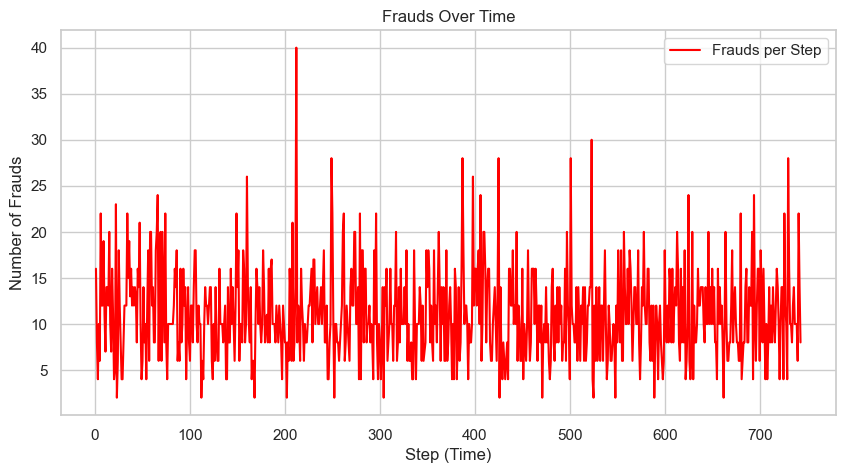

In [91]:
# Lấy số lượng gian lận theo từng step (thời gian)
frauds_per_step = df[df["isFraud"] == 1]["step"].value_counts().sort_index()

# Sửa lại thành frauds_per_step.index cho cả trục X và trục Y
plt.figure(figsize=(10, 5))
plt.plot(frauds_per_step.index, frauds_per_step.values, label="Frauds per Step", color="red")
plt.xlabel("Step (Time)")
plt.ylabel("Number of Frauds")
plt.title("Frauds Over Time")
plt.grid(True)
plt.legend()
plt.show()

vẽ biểu đồ đường (Line Chart) thể hiện xu hướng số lượng vụ gian lận thay đổi như thế nào theo thời gian (step).

https://www.kaggle.com/datasets/amanalisiddiqui/fraud-detection-dataset?resource=download

Dataset "Fraud Detection Dataset" trên Kaggle của tác giả Aman Ali Siddiqui là một tập dữ liệu rất nổi tiếng (thường bắt nguồn từ mô phỏng dữ liệu giao dịch tài chính di động/Mobile Money, tương tự như bài toán kinh điển PaySim).   

1. Bản chất của Dataset này là gì?Mục tiêu: Xây dựng mô hình Machine Learning để phân loại/dự đoán xem một giao dịch tài chính có phải là gian lận (Fraud) hay không (Bài toán Phân loại nhị phân - Binary Classification: 0 là giao dịch bình thường, 1 là gian lận).Đặc thù lớn nhất: Đây là bài toán mất cân bằng dữ liệu cực đoan (Class Imbalance). Trong thực tế, số lượng giao dịch gian lận chiếm tỷ lệ vô cùng nhỏ (thường dưới 1%), còn lại hơn 99% là giao dịch hợp lệ. Nếu bạn dùng mô hình dự đoán toàn là "0" thì độ chính xác (Accuracy) vẫn có thể lên tới 99% nhưng mô hình lại hoàn toàn vô tích sự vì bỏ sót 100% các vụ lừa đảo.   

2. Các cột dữ liệu (Features) thường gặp trong Dataset này:   Mặc dù các biến có thể dao động tùy theo phiên bản file CSV cụ thể, tập dữ liệu này mô phỏng các giao dịch ngân hàng/ví điện tử qua các cột chính sau:   step: Đại diện cho đơn vị thời gian (ví dụ: 1 bước = 1 giờ). Tổng số step thường kéo dài qua nhiều ngày để thấy chuỗi thời gian diễn ra giao dịch.type: Loại giao dịch tài chính, bao gồm các hình thức phổ biến:CASH-IN: Nạp tiền vào tài khoản.CASH-OUT: Rút tiền mặt từ merchant/tài khoản.DEBIT: Chuyển tiền từ dịch vụ di động sang tài khoản ngân hàng.   PAYMENT: Thanh toán mua sắm hàng hóa/dịch vụ.TRANSFER: Chuyển khoản cho người dùng khác trên cùng nền tảng.amount: Số tiền của giao dịch (Giao dịch gian lận thường có các khoản tiền bất thường so với lịch sử người dùng).   nameOrig: Mã định danh (ID) của khách hàng thực hiện giao dịch trước khi chuyển đi.oldbalanceOrg: Số dư tài khoản của người gửi trước khi thực hiện giao dịch.newbalanceOrig: Số dư tài khoản của người gửi sau khi thực hiện giao dịch.nameDest: Mã định danh (ID) của người nhận tiền phía bên kia.oldbalanceDest: Số dư ban đầu của người nhận trước khi nhận tiền.newbalanceDest: Số dư của người nhận sau khi nhận tiền.isFraud: Nhãn mục tiêu (Target Label) cần dự đoán. 1 nếu là giao dịch gian lận do kẻ gian chiếm đoạt tài khoản chuyển tiền đi, 0 nếu là giao dịch sạch.isFlaggedFraud: Cờ cảnh báo của hệ thống quy tắc cũ (Rule-based system) khi phát hiện một giao dịch có số tiền chuyển khoản quá lớn trong một lần (thường là > 200,000).

3. Những điểm cần lưu ý khi làm Machine Learning với Dataset này:Không dùng mô hình Hồi quy tuyến tính (Linear Regression):Vì bài toán này là Phân loại (Classification) chứ không phải dự đoán giá trị liên tục như dự đoán điểm số (Exam Score), bạn phải chuyển sang dùng các mô hình phân loại như:   LogisticRegression (Hồi quy logistic)RandomForestClassifier (Rừng ngẫu nhiên phân loại)XGBoost / LightGBM (Các mô hình cực mạnh chuyên trị dữ liệu bảng và chống mất cân bằng dữ liệu).Cách xử lý dữ liệu mất cân bằng (Imbalanced Data):Phải dùng kỹ thuật cân bằng dữ liệu như SMOTE (Synthetic Minority Over-sampling Technique) để sinh thêm mẫu giả lập cho bên gian lận.Không dùng độ đo Accuracy để đánh giá mô hình. Thay vào đó, bắt buộc phải dùng Precision, Recall, F1-Score và đặc biệt là ROC-AUC Score.   Feature Engineering (Tạo đặc trưng mới):Bạn có thể tự tạo thêm các cột mới để giúp mô hình thông minh hơn, ví dụ:Kiểm tra xem số dư sau giao dịch của người gửi (newbalanceOrig) có khớp với công thức oldbalanceOrg - amount hay không (kẻ gian thường làm lệch con số này).Tính toán độ lệch số tiền so với mức trung bình của tài khoản đó.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import warnings
warnings.filterwarnings("ignore")
sns.set(style="whitegrid")

In [ ]:
df = pd.read_csv("AIML Dataset.csv")

In [ ]:
df.shape

(6362620, 11)

In [ ]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [ ]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

In [ ]:
df["isFraud"].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [ ]:
df["isFlaggedFraud"].value_counts()

isFlaggedFraud
0    6362604
1         16
Name: count, dtype: int64

In [ ]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
# % is Fraud / all data
round((df["isFraud"].value_counts()[1] / df.shape[0]) *100,2)

np.float64(0.13)

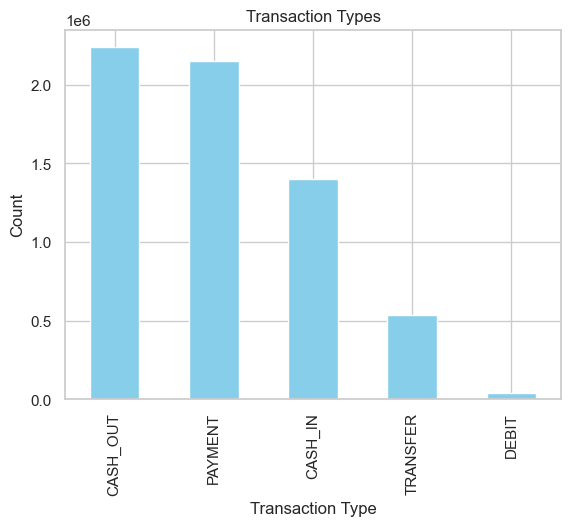

In [ ]:
df["type"].value_counts().plot(kind='bar', title="Transaction Types", color="skyblue")
plt.xlabel("Transaction Type")
plt.ylabel("Count")
plt.show()

Text(0, 0.5, 'Fraud Rate')

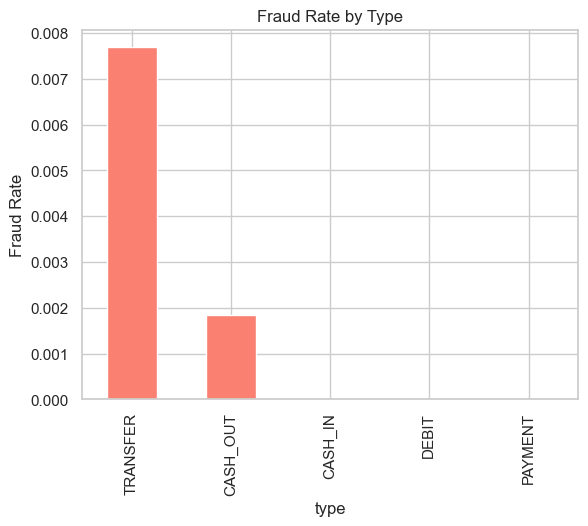

In [ ]:
fraud_by_type = df.groupby("type")["isFraud"].mean().sort_values(ascending=False)
fraud_by_type.plot(kind="bar", title="Fraud Rate by Type", color="salmon")
plt.ylabel("Fraud Rate")

In [ ]:
fraud_by_type

type
TRANSFER    0.007688
CASH_OUT    0.001840
CASH_IN     0.000000
DEBIT       0.000000
PAYMENT     0.000000
Name: isFraud, dtype: float64

In [ ]:
df["amount"].describe().astype(int)

count     6362620
mean       179861
std        603858
min             0
25%         13389
50%         74871
75%        208721
max      92445516
Name: amount, dtype: int64

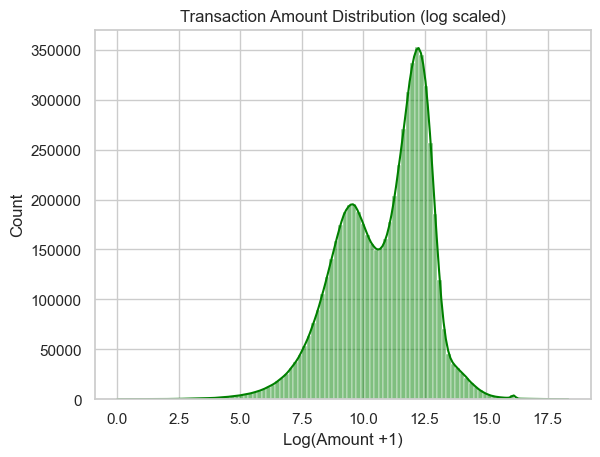

In [ ]:
sns.histplot(np.log1p(df["amount"]), bins=100, kde=True, color="green")
plt.title("Transaction Amount Distribution (log scaled)")
plt.xlabel("Log(Amount +1)")
plt.show()

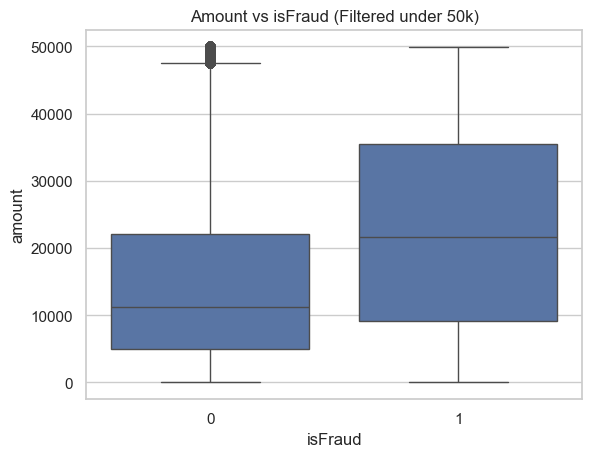

In [ ]:
sns.boxplot(data=df[df["amount"] < 50000], x = "isFraud", y="amount")
plt.title("Amount vs isFraud (Filtered under 50k)")
plt.show()

In [ ]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

In [ ]:
df["balanceDiffOrig"] = df["oldbalanceOrg"] - df["newbalanceOrig"]
df["balanceDiffDest"] = df["newbalanceDest"] - df["oldbalanceDest"]



In [ ]:
(df["balanceDiffOrig"] < 0).sum()

np.int64(1399253)

In [ ]:
(df["balanceDiffDest"] < 0).sum()

np.int64(1238864)

In [ ]:
df.head()

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOrig,balanceDiffDest
0,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,9839.64,0.0
1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,1864.28,0.0
2,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,181.00,0.0
3,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,181.00,-21182.0
4,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,11668.14,0.0


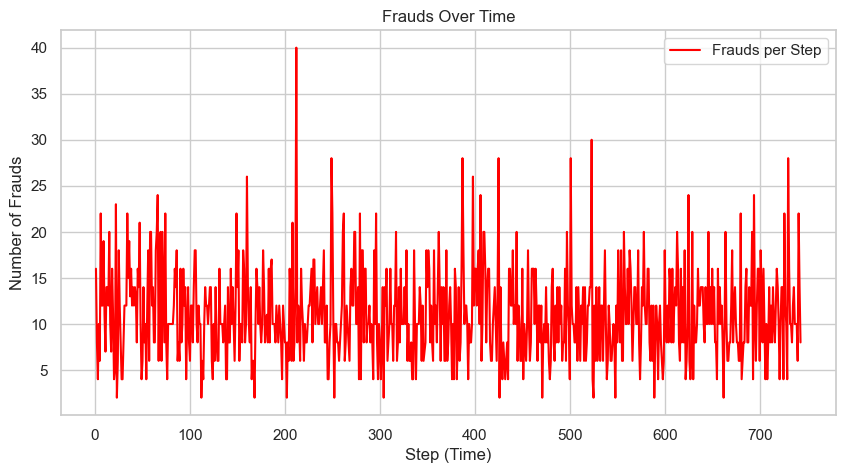

In [ ]:
# Lấy số lượng gian lận theo từng step (thời gian)
frauds_per_step = df[df["isFraud"] == 1]["step"].value_counts().sort_index()

# Sửa lại thành frauds_per_step.index cho cả trục X và trục Y
plt.figure(figsize=(10, 5))
plt.plot(frauds_per_step.index, frauds_per_step.values, label="Frauds per Step", color="red")
plt.xlabel("Step (Time)")
plt.ylabel("Number of Frauds")
plt.title("Frauds Over Time")
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
df.drop(columns="step", inplace=True)

In [ ]:
df.head()

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOrig,balanceDiffDest
0,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,9839.64,0.0
1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,1864.28,0.0
2,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,181.00,0.0
3,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,181.00,-21182.0
4,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,11668.14,0.0


In [ ]:
top_senders = df["nameOrig"].value_counts().head(10)

In [ ]:
top_senders

nameOrig
C1677795071    3
C1999539787    3
C724452879     3
C1976208114    3
C400299098     3
C1784010646    3
C1530544995    3
C1065307291    3
C545315117     3
C1902386530    3
Name: count, dtype: int64

In [ ]:
top_receivers = df["nameDest"].value_counts().head(10)

In [ ]:
top_receivers

nameDest
C1286084959    113
C985934102     109
C665576141     105
C2083562754    102
C248609774     101
C1590550415    101
C1789550256     99
C451111351      99
C1360767589     98
C1023714065     97
Name: count, dtype: int64

In [ ]:
fraud_users = df[df["isFraud"] == 1]["nameOrig"].value_counts().head(10)

In [ ]:
fraud_users

nameOrig
C1305486145    1
C840083671     1
C1420196421    1
C2101527076    1
C137533655     1
C1118430673    1
C749981943     1
C1334405552    1
C467632528     1
C1364127192    1
Name: count, dtype: int64

In [ ]:
fraud_types = df[df["type"].isin(["TRANSFER", "CASH_OUT"])]

In [ ]:
fraud_types["type"].value_counts()

type
CASH_OUT    2237500
TRANSFER     532909
Name: count, dtype: int64

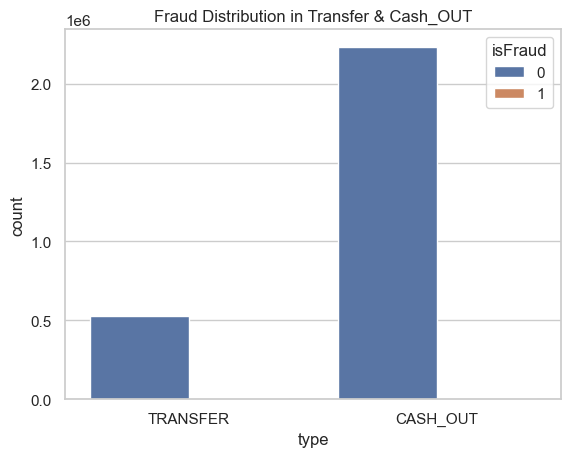

In [ ]:
sns.countplot(data=fraud_types, x="type", hue="isFraud")
plt.title("Fraud Distribution in Transfer & Cash_OUT")
plt.show()

In [ ]:
df.columns

Index(['type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud', 'balanceDiffOrig', 'balanceDiffDest'],
      dtype='object')

In [ ]:
corr = df[["amount", "oldbalanceOrg", "newbalanceOrig", "oldbalanceDest", "newbalanceDest", "isFraud"]].corr()

In [ ]:
corr

,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
amount,1.000000,-0.002762,-0.007861,0.294137,0.459304,0.076688
oldbalanceOrg,-0.002762,1.000000,0.998803,0.066243,0.042029,0.010154
newbalanceOrig,-0.007861,0.998803,1.000000,0.067812,0.041837,-0.008148
oldbalanceDest,0.294137,0.066243,0.067812,1.000000,0.976569,-0.005885
newbalanceDest,0.459304,0.042029,0.041837,0.976569,1.000000,0.000535
isFraud,0.076688,0.010154,-0.008148,-0.005885,0.000535,1.000000


Text(0.5, 1.0, 'Correlation Matrix')

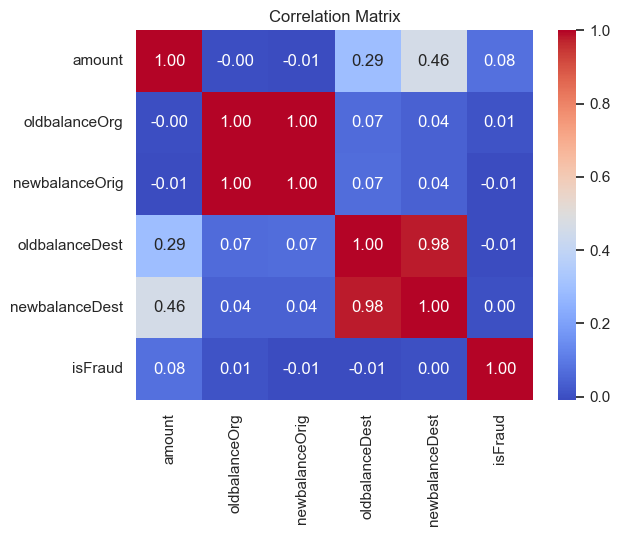

In [ ]:
sns.heatmap(corr, annot= True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")

In [ ]:
zero_after_transfer = df[
    (df["oldbalanceOrg"] > 0) &
    (df["newbalanceOrig"] == 0) &
    (df["type"].isin(["TRANSFER", "CASH_OUT"]))
]

In [ ]:
len(zero_after_transfer)

1188074

In [ ]:
zero_after_transfer.head()

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOrig,balanceDiffDest
2,TRANSFER,181.00,C1305486145,181.0,0.0,C553264065,0.0,0.00,1,0,181.0,0.00
3,CASH_OUT,181.00,C840083671,181.0,0.0,C38997010,21182.0,0.00,1,0,181.0,-21182.00
15,CASH_OUT,229133.94,C905080434,15325.0,0.0,C476402209,5083.0,51513.44,0,0,15325.0,46430.44
19,TRANSFER,215310.30,C1670993182,705.0,0.0,C1100439041,22425.0,0.00,0,0,705.0,-22425.00
24,TRANSFER,311685.89,C1984094095,10835.0,0.0,C932583850,6267.0,2719172.89,0,0,10835.0,2712905.89


In [ ]:
df["isFraud"].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

train_test_split: Dùng để chia tập dữ liệu tổng thành 2 phần: Tập huấn luyện (X_train, y_train) để mô hình học và tập kiểm thử (X_test, y_test) để đánh giá độ chính xác độc lập.

StandardScaler: Chuẩn hóa các cột dữ liệu số (như amount, oldbalanceOrg...) về cùng một thang đo (có trung bình bằng 0 và độ lệch chuẩn bằng 1). Việc này giúp mô hình Logistic Regression hội tụ nhanh hơn và không bị "thiên vị" các cột có số quá lớn.

OneHotEncoder: Chuyển đổi các cột dạng chữ phân loại (ví dụ cột type với các giá trị như TRANSFER, CASH_OUT...) thành các cột dạng số nhị phân (0 hoặc 1) vì thuật toán Machine Learning không hiểu chữ cái trực tiếp.

ColumnTransformer: Cỗ máy trung gian giúp bạn xử lý "song song": cột nào dạng số thì đưa qua StandardScaler, cột nào dạng chữ thì đưa qua OneHotEncoder.

Pipeline: Đóng gói toàn bộ các bước tiền xử lý (ColumnTransformer) và mô hình (LogisticRegression) lại thành một "đường ống" duy nhất. Nhờ có Pipeline này mà khi bạn làm file Streamlit (app.py), bạn chỉ cần truyền dữ liệu thô vào là nó tự xử lý từ A-Z.

LogisticRegression: Thuật toán phân loại nhị phân (được bạn cấu hình thêm class_weight="balanced" để xử lý vấn đề mất cân bằng dữ liệu).

classification_report và confusion_matrix: Các công cụ đo lường và đánh giá chất lượng mô hình, giúp bạn xem được chính xác các chỉ số như Precision, Recall, F1-Score và ma trận nhầm lẫn.



In [ ]:
df.head()

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOrig,balanceDiffDest
0,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,9839.64,0.0
1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,1864.28,0.0
2,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,181.00,0.0
3,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,181.00,-21182.0
4,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,11668.14,0.0


In [ ]:
df_model =df.drop(["nameOrig", "nameDest", "isFlaggedFraud"], axis=1)

In [ ]:
df_model.head()

,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,balanceDiffOrig,balanceDiffDest
0,PAYMENT,9839.64,170136.0,160296.36,0.0,0.0,0,9839.64,0.0
1,PAYMENT,1864.28,21249.0,19384.72,0.0,0.0,0,1864.28,0.0
2,TRANSFER,181.00,181.0,0.00,0.0,0.0,1,181.00,0.0
3,CASH_OUT,181.00,181.0,0.00,21182.0,0.0,1,181.00,-21182.0
4,PAYMENT,11668.14,41554.0,29885.86,0.0,0.0,0,11668.14,0.0


In [ ]:
categorical = ["type"]
numeric = ["amount", "oldbalanceOrg", "newbalanceOrig", "oldbalanceDest", "newbalanceDest"]

In [ ]:
y = df_model["isFraud"]
X = df_model.drop("isFraud", axis=1)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y)

In [ ]:
preprocessor = ColumnTransformer(
    transformers= [
        ("num", StandardScaler(), numeric),
        ("cat", OneHotEncoder(drop="first"), categorical)
    ],
    remainder="drop"
)

ColumnTransformer, một "cỗ máy phân luồng" dữ liệu thông minh trong Scikit-learn giúp xử lý đồng thời cả cột dạng số (numeric) và cột dạng chữ (categorical) trước khi đưa vào mô hình.

1. transformers=[...]
Phần này định nghĩa các nhóm cột nào sẽ đi qua thuật toán xử lý nào:

("num", StandardScaler(), numeric):

Đặt tên nhóm là "num".

Áp dụng bộ chuẩn hóa StandardScaler() (đưa về thang đo chuẩn, trung bình = 0, độ lệch chuẩn = 1).

Áp dụng riêng cho danh sách các cột số (numeric gồm: amount, oldbalanceOrg, newbalanceOrig, oldbalanceDest, newbalanceDest).

("cat", OneHotEncoder(drop="first"), categorical):

Đặt tên nhóm là "cat".

Áp dụng bộ mã hóa OneHotEncoder(drop="first") (chuyển chữ thành các cột nhị phân 0/1, đồng thời tham số drop="first" giúp xóa bớt một cột đầu tiên để tránh hiện tượng đa cộng tuyến - multicollinearity).

Áp dụng riêng cho danh sách các cột phân loại (categorical gồm cột type).

2. remainder="drop"
Tham số này quyết định số phận của các cột còn lại (nếu có trong DataFrame nhưng không nằm trong danh sách numeric hay categorical).

Với giá trị "drop", bất kỳ cột nào không được gọi tên trong transformers sẽ bị vứt bỏ hoàn toàn và không được đưa vào mô hình.

In [ ]:
pipeline = Pipeline([
    ("prep", preprocessor),
    ("clf", LogisticRegression(class_weight="balanced", max_iter=1000))
])

để đóng gói toàn bộ quy trình từ tiền xử lý dữ liệu đến mô hình huấn luyện thành một "đường ống" (Pipeline) duy nhất trong Scikit-learn.

1. ("prep", preprocessor)
Bước 1 (Tiền xử lý): Đặt tên bước này là "prep". Nó sẽ nhận dữ liệu thô đầu vào và áp dụng toàn bộ các luật xử lý đã định nghĩa ở ColumnTransformer phía trên (chuẩn hóa cột số bằng StandardScaler và mã hóa cột chữ bằng OneHotEncoder).

2. ("clf", LogisticRegression(class_weight="balanced", max_iter=1000))
Bước 2 (Mô hình phân loại): Đặt tên bước này là "clf" (viết tắt của classifier).

Sử dụng thuật toán LogisticRegression với các tham số quan trọng:

class_weight="balanced": Đây là "vũ khí" cực kỳ quan trọng để xử lý bài toán mất cân bằng dữ liệu (như dataset PaySim của bạn khi số lượng giao dịch gian lận chiếm tỷ lệ quá nhỏ). Tham số này tự động tính toán và gán trọng số phạt lớn hơn cho nhóm gian lận, buộc mô hình phải chú ý đến chúng thay vì dự đoán bừa là "bình thường" để lấy độ chính xác cao ảo.

max_iter=1000: Cho phép thuật toán lặp tối đa 1,000 lần (iterations) trong quá trình tối ưu hóa (gradient descent) để đảm bảo mô hình có đủ thời gian hội tụ, tránh gặp lỗi cảnh báo chưa hội tụ (ConvergenceWarning).

In [ ]:
pipeline.fit(X_train, y_train)

,steps,"[('prep', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [ ]:
y_pred = pipeline.predict(X_test)

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.95      0.97   1906322
           1       0.02      0.94      0.04      2464

    accuracy                           0.95   1908786
   macro avg       0.51      0.94      0.51   1908786
weighted avg       1.00      0.95      0.97   1908786



1. Các thuật ngữ cơ bản (Dựa trên Ma trận nhầm lẫn - Confusion Matrix)
Để hiểu các chỉ số, ta quy ước:

True Positive (TP): Mô hình dự đoán là Gian lận, và thực tế đúng là Gian lận.

False Positive (FP): Mô hình dự đoán là Gian lận, nhưng thực tế là Bình thường (Báo động giả).

False Negative (FN): Mô hình dự đoán là Bình thường, nhưng thực tế lại là Gian lận (Bỏ sót tội phạm).

True Negative (TN): Mô hình dự đoán là Bình thường, và thực tế đúng là Bình thường.

2. Các cột chỉ số trong bảngprecision (Độ chính xác của dự đoán):Công thức: $\text{Precision} = \frac{\text{TP}}{\text{TP} + \text{FP}}$Ý nghĩa: Trong số tất cả những lần mô hình cảnh báo là gian lận, có bao nhiêu phần trăm là đúng là gian lận thật?Ví dụ ở hàng 1 (nhóm 1): Precision = 0.02 (2%). Cứ 100 lần mô hình thét lên "Có gian lận!", thì có tới 98 lần là nhầm lẫn (bình thường), chỉ đúng được 2 lần.

recall (Độ nhạy / Khả năng quét sạch mục tiêu):Công thức: $\text{Recall} = \frac{\text{TP}}{\text{TP} + \text{FN}}$Ý nghĩa: Trong số tất cả các vụ gian lận thực tế đang có trong tập dữ liệu, mô hình đã tóm được bao nhiêu phần trăm?Ví dụ ở hàng 1 (nhóm 1): Recall = 0.94 (94%). Thực tế có 100 vụ lừa đảo, mô hình quét và phát hiện được tới 94 vụ, chỉ bỏ lọt 6 vụ. (Đây là điểm sáng của mô hình bạn).

f1-score (Điểm cân bằng):Công thức: Trung bình điều hòa giữa Precision và Recall: $2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$Ý nghĩa: Kết hợp cả Precision và Recall thành một con số duy nhất để đánh giá xem mô hình có bị lệch lạc quá không. F1-score càng gần 1.0 nghĩa là mô hình càng hoàn hảo ở cả 2 mặt (vừa bắt chuẩn vừa ít báo động giả).

support (Số lượng mẫu thực tế):Ý nghĩa: Số lượng dòng dữ liệu thực tế của từng nhóm trong tập kiểm thử (y_test).Ví dụ: Nhóm 0 (bình thường) có tới 1,906,322 giao dịch, trong khi nhóm 1 (gian lận) chỉ có vỏn vẹn 2,464 giao dịch. Con số này thể hiện rõ độ lệch dữ liệu khổng lồ.   

3. Các dòng tổng kết phía dướiaccuracy (Độ chính xác tổng thể):Ý nghĩa: Tỷ lệ đoán đúng trên tổng số tất cả các giao dịch. Ở đây là 0.95 (95%). Tuy nhiên, như đã phân tích, con số này không có nhiều ý nghĩa thực tiễn trong bài toán mất cân bằng dữ liệu vì phần lớn 95% đó chủ yếu đến từ việc mô hình đoán đúng các giao dịch bình thường quá nhiều.   macro avg (Trung bình vĩ mô):Lấy trung bình cộng đơn thuần các chỉ số của nhóm 0 và nhóm 1 mà không quan tâm đến số lượng mẫu nhiều hay ít.weighted avg (Trung bình trọng số):Lấy trung bình cộng có tính đến trọng số là số lượng mẫu (support). Vì nhóm 0 chiếm áp đảo (hơn 1.9 triệu mẫu), nên điểm weighted avg của cột Precision bị kéo sát về 1.00 nhờ vào độ chính xác tuyệt đối của nhóm 0.   


2. Góc nhìn "Chưa ổn" (Báo động giả liên tục)Nhìn vào cột Precision = 0.02 của nhóm 1: Cứ 100 lần mô hình cảnh báo "Có giao dịch lừa đảo!", thì có tới 98 lần là cảnh báo nhầm (giao dịch của khách thật nhưng mô hình tưởng là trộm).   Nếu đưa mô hình này vào thực tế vận hành cho ngân hàng, các nhân viên trực tổng đài hoặc khách hàng sẽ phát điên vì liên tục nhận được tin nhắn/cảnh báo khóa thẻ oan.

In [ ]:
confusion_matrix(y_test, y_pred)

array([[1804449,  101873],
       [    145,    2319]])

In [ ]:
pipeline.score(X_test, y_test) *100

94.65534638246508

In [ ]:
import joblib

joblib.dump(pipeline, "fraud_detection_pipeline.pkl")

['fraud_detection_pipeline.pkl']

In [92]:
df.drop(columns="step", inplace=True)

In [93]:
df.head()

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOrig,balanceDiffDest
0,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,9839.64,0.0
1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,1864.28,0.0
2,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,181.00,0.0
3,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,181.00,-21182.0
4,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,11668.14,0.0


In [94]:
top_senders = df["nameOrig"].value_counts().head(10)

In [95]:
top_senders

nameOrig
C1677795071    3
C1999539787    3
C724452879     3
C1976208114    3
C400299098     3
C1784010646    3
C1530544995    3
C1065307291    3
C545315117     3
C1902386530    3
Name: count, dtype: int64

In [96]:
top_receivers = df["nameDest"].value_counts().head(10)

In [97]:
top_receivers

nameDest
C1286084959    113
C985934102     109
C665576141     105
C2083562754    102
C248609774     101
C1590550415    101
C1789550256     99
C451111351      99
C1360767589     98
C1023714065     97
Name: count, dtype: int64

In [102]:
fraud_users = df[df["isFraud"] == 1]["nameOrig"].value_counts().head(10)

In [103]:
fraud_users

nameOrig
C1305486145    1
C840083671     1
C1420196421    1
C2101527076    1
C137533655     1
C1118430673    1
C749981943     1
C1334405552    1
C467632528     1
C1364127192    1
Name: count, dtype: int64

In [104]:
fraud_types = df[df["type"].isin(["TRANSFER", "CASH_OUT"])]

In [105]:
fraud_types["type"].value_counts()

type
CASH_OUT    2237500
TRANSFER     532909
Name: count, dtype: int64

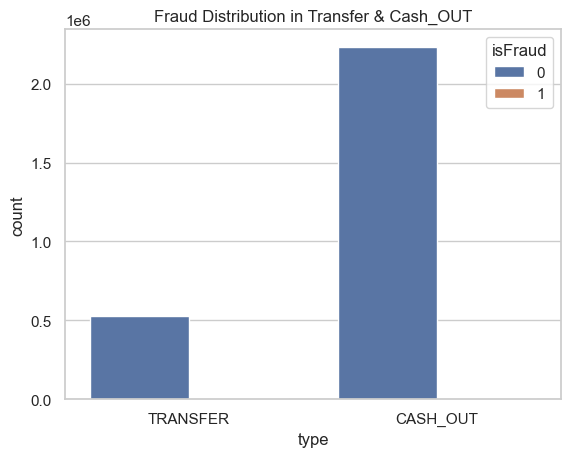

In [106]:
sns.countplot(data=fraud_types, x="type", hue="isFraud")
plt.title("Fraud Distribution in Transfer & Cash_OUT")
plt.show()

In [108]:
df.columns

Index(['type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud', 'balanceDiffOrig', 'balanceDiffDest'],
      dtype='object')

In [110]:
corr = df[["amount", "oldbalanceOrg", "newbalanceOrig", "oldbalanceDest", "newbalanceDest", "isFraud"]].corr()

In [111]:
corr

,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
amount,1.000000,-0.002762,-0.007861,0.294137,0.459304,0.076688
oldbalanceOrg,-0.002762,1.000000,0.998803,0.066243,0.042029,0.010154
newbalanceOrig,-0.007861,0.998803,1.000000,0.067812,0.041837,-0.008148
oldbalanceDest,0.294137,0.066243,0.067812,1.000000,0.976569,-0.005885
newbalanceDest,0.459304,0.042029,0.041837,0.976569,1.000000,0.000535
isFraud,0.076688,0.010154,-0.008148,-0.005885,0.000535,1.000000


Text(0.5, 1.0, 'Correlation Matrix')

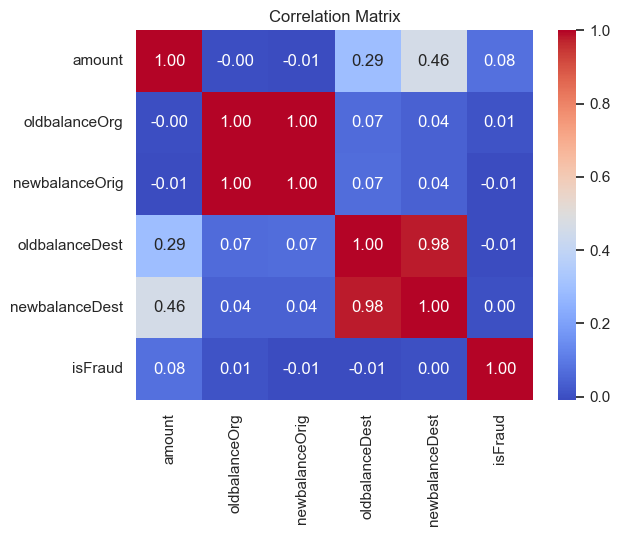

In [113]:
sns.heatmap(corr, annot= True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")

In [114]:
zero_after_transfer = df[
    (df["oldbalanceOrg"] > 0) &
    (df["newbalanceOrig"] == 0) &
    (df["type"].isin(["TRANSFER", "CASH_OUT"]))
]

In [115]:
len(zero_after_transfer)

1188074

In [116]:
zero_after_transfer.head()

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOrig,balanceDiffDest
2,TRANSFER,181.00,C1305486145,181.0,0.0,C553264065,0.0,0.00,1,0,181.0,0.00
3,CASH_OUT,181.00,C840083671,181.0,0.0,C38997010,21182.0,0.00,1,0,181.0,-21182.00
15,CASH_OUT,229133.94,C905080434,15325.0,0.0,C476402209,5083.0,51513.44,0,0,15325.0,46430.44
19,TRANSFER,215310.30,C1670993182,705.0,0.0,C1100439041,22425.0,0.00,0,0,705.0,-22425.00
24,TRANSFER,311685.89,C1984094095,10835.0,0.0,C932583850,6267.0,2719172.89,0,0,10835.0,2712905.89


In [117]:
df["isFraud"].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [118]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [119]:
df.head()

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOrig,balanceDiffDest
0,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,9839.64,0.0
1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,1864.28,0.0
2,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,181.00,0.0
3,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,181.00,-21182.0
4,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,11668.14,0.0


In [120]:
df_model =df.drop(["nameOrig", "nameDest", "isFlaggedFraud"], axis=1)

In [121]:
df_model.head()

,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,balanceDiffOrig,balanceDiffDest
0,PAYMENT,9839.64,170136.0,160296.36,0.0,0.0,0,9839.64,0.0
1,PAYMENT,1864.28,21249.0,19384.72,0.0,0.0,0,1864.28,0.0
2,TRANSFER,181.00,181.0,0.00,0.0,0.0,1,181.00,0.0
3,CASH_OUT,181.00,181.0,0.00,21182.0,0.0,1,181.00,-21182.0
4,PAYMENT,11668.14,41554.0,29885.86,0.0,0.0,0,11668.14,0.0


In [122]:
categorical = ["type"]
numeric = ["amount", "oldbalanceOrg", "newbalanceOrig", "oldbalanceDest", "newbalanceDest"]

In [124]:
y = df_model["isFraud"]
X = df_model.drop("isFraud", axis=1)

In [125]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y)

In [126]:
preprocessor = ColumnTransformer(
    transformers= [
        ("num", StandardScaler(), numeric),
        ("cat", OneHotEncoder(drop="first"), categorical)
    ],
    remainder="drop"
)

In [127]:
pipeline = Pipeline([
    ("prep", preprocessor),
    ("clf", LogisticRegression(class_weight="balanced", max_iter=1000))
])

In [128]:
pipeline.fit(X_train, y_train)

,steps,"[('prep', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [129]:
y_pred = pipeline.predict(X_test)

In [131]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.95      0.97   1906322
           1       0.02      0.94      0.04      2464

    accuracy                           0.95   1908786
   macro avg       0.51      0.94      0.51   1908786
weighted avg       1.00      0.95      0.97   1908786



In [132]:
confusion_matrix(y_test, y_pred)

array([[1804449,  101873],
       [    145,    2319]])

In [134]:
pipeline.score(X_test, y_test) *100

94.65534638246508

In [135]:
import joblib

joblib.dump(pipeline, "fraud_detection_pipeline.pkl")

['fraud_detection_pipeline.pkl']